# ECG Arrhythmia Detection Using Machine Learning

**Authors:** 



---

## Introduction

Cardiac arrhythmias are irregular heartbeat conditions caused by abnormal electrical activity in the heart. If left undiagnosed, they can lead to serious complications including sudden cardiac death. The standard diagnostic tool is the electrocardiogram (ECG), which records the heart's electrical activity over time.

The goal of this project was to build a binary classifier that labels ECG signal segments as either **normal** or **abnormal**, using two machine learning models. Through our research, we selected the following models: Support Vector Machine (SVM) and Gradient Boosting [1, 2, 3].

---

## Dataset and preprocessing

The dataset consists of raw ECG signal files sampled at 360 Hz, organized into `Data/normal/` and `Data/abnormal/` folders. We used this when loading the signals to create labels for them.

Raw ECG signals contain noise and artifacts that obscure clinically relevant features. The preprocessing pipeline consisted of min-max normalization, resampling to 200 Hz, and bandpass filtering (0.5–40 Hz butterworth) to remove baseline wander and high/low-frequency noise.

R-peak detection was performed using the Pan-Tompkins algorithm [6].

---

## Initial models and results

Two classifiers were trained on a 70/30 train/test split:

| Model | Baseline Accuracy |
|---|---|
| SVM | 0.8798 |
| Gradient Boosting | 0.9000 |

Performance plateaued around 90%. Confusion matrices showed both models struggled with some specific cases between normal and abnormal signals. Testing different hyperparameters only got us to this best results.

---

## Literature review and feature expansion

As we weren't satisfied with the results, we reviewed different literature [1, 2, 3, 4, 5]. The research papers highlighted that others were extracting different features, which provided stronger discriminatory signals. 

So we implemented discrete wavelet transform and added additional statistical features.

---

## Final results with additional features

After retraining with the expanded feature set and hyperparameter tuning via `GridSearchCV`:

| Model | Baseline Accuracy | Tuned F1-Score |
|---|---|---|
| SVM (RBF kernel) | 0.8798 | 0.885 |
| Gradient Boosting | 0.9000 | **0.951** |

Gradient Boosting showed the largest improvement, confirming that the additional features added meaningful input.

---

## Conclusion and future work

The tuned Gradient Boosting classifier is our best performing model. After this, we though about two directions for future work:

1. **Increase model complexity** — push parameter counts further to empirically identify the overfitting threshold. Parameters were intentionally capped in this project to not push computational complexity.

2. **Feature selection** — reduce the feature set using importance scores, shrinking model size and trying to keep the same accuracy scores. This could also help medicaly understand what matters in this setting.

---

## References

[1] S. Dhyani and A. Kumar and S. Choudhury, "Analysis of ECG-based arrhythmia detection system using machine learning," *IETE Journal of Research*, 2021.

[2] S. Sahoo, M. Dash, S. Behera, and S. Sabut, "Machine Learning Approach to Detect Cardiac Arrhythmias in ECG Signals: A Survey," *IOP Conference Series*, 2020.

[3] R. Saboori, A. W. Salehi, P. Vaidya, and G. Gupta, "Classification of Arrhythmia Using Machine Learning Techniques," 2021.

[4] M. A. Nauman, C. Failor, and W. Saadeh, "Cardiac Arrhythmias Classification Using Machine Learning and Single-Lead ECG," *IEEE*, 2023.

[5] T. Soman and P. O. Bobbie, "Classification of arrhythmia using machine learning techniques," *WSEAS Transactions on Computers*, vol. 4, no. 6, pp. 548–552, 2005.

[6] J. Pan and W. J. Tompkins, "A real-time QRS detection algorithm," *IEEE Transactions on Biomedical Engineering*, vol. 32, no. 3, pp. 230–236, 1985.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os



from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn import svm
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

### init step: Load ECG Data

Num. of normal signals: 3855 - should be 3855
Num. of abnormal signals: 4046 - should be 4046


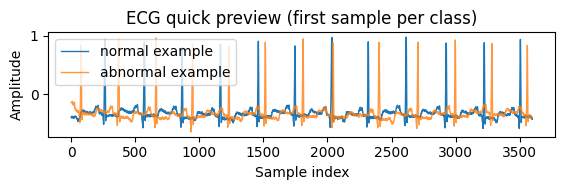

In [2]:
# where is data stored (subfolders should be abnormal, normal)
data_path = Path("Data")


def load_ecg_csv_dataset(root_dir: Path):
    """
    Load ecg from CSV files organized as class subfolders(normal/abnormal)
    """
    # define where to find csv files
    normal_files_path = sorted((root_dir / "normal").rglob("*.csv"))
    abnormal_files_path = sorted((root_dir / "abnormal").rglob("*.csv"))


    # this will be output/returned
    normal_signals, abnormal_signals = [], []


    for csv_path in normal_files_path:
        signal = np.loadtxt(csv_path, delimiter=",", skiprows=1, dtype=float)
        normal_signals.append(np.asarray(signal, dtype=float).reshape(-1))

    for csv_path in abnormal_files_path:
        signal = np.loadtxt(csv_path, delimiter=",", skiprows=1, dtype=float)
        abnormal_signals.append(np.asarray(signal, dtype=float).reshape(-1))

    return normal_signals, abnormal_signals


# call function to load
normal_signals, abnormal_signals = load_ecg_csv_dataset(data_path)

# merge together, so we have both
signals = normal_signals + abnormal_signals
class_labels = (["normal"] * len(normal_signals)) + (["abnormal"] * len(abnormal_signals))


print(f"Num. of normal signals: {len(normal_signals)} - should be 3855")
print(f"Num. of abnormal signals: {len(abnormal_signals)} - should be 4046")


# visual check of loaded signal
plt.figure(figsize=(6, 2))
plt.plot(normal_signals[0], label="normal example", linewidth=1)
plt.plot(abnormal_signals[0], label="abnormal example", linewidth=1, alpha=0.8)
plt.title("ECG quick preview (first sample per class)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

## Step 1

Pre processing
 - normalization with min max
 - resampling to 200hz
 - filtering

Processed 7901 signals.


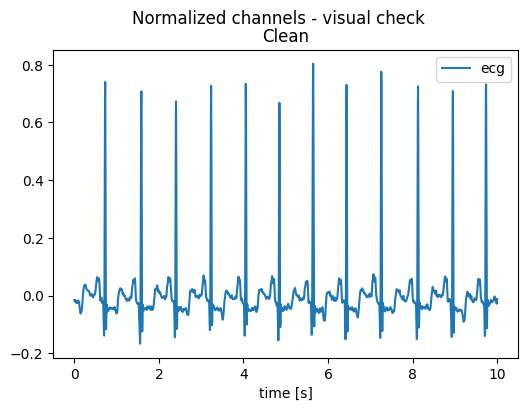

In [3]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ============ Helper functions ==============
def minmax_normalize(chan: np.ndarray, min_value: int = 0, max_value: int = 1):
    """
    Map the given channel to the given range
    """
    chan = (chan - np.min(chan)) / (np.max(chan) - np.min(chan))
    return chan * (max_value - min_value) + min_value

def new_time_vector(df: pd.DataFrame, fs_new: int) -> list[float]:
    """
    Compute a new time array which is an approximation of the given timestamps
    """
    min_dt = df['timestamps_ecg'].iloc[-1]
    sampling_period = 1/fs_new
    n = fs_new * min_dt
    return np.arange(n + 1) * sampling_period

def resample(chan: np.ndarray, orig_ts: np.ndarray, new_ts: np.ndarray) -> list[float]:
    """
    Resample the given channel to the given length
    """
    sampled_signal = interp1d(orig_ts, chan, kind='cubic', bounds_error=False, fill_value="extrapolate")
    return sampled_signal(new_ts)

def butter_filter(chan: np.ndarray, fs: int, N: int = 3, lf: float = 0.5, hf: float = 40):
    """
    Apply a Butterworth Bandpass filter.
    """
    b, a = butter(N, [lf, hf], fs=fs, btype='bandpass')
    return filtfilt(b, a, chan)

def preprocess_pipeline(df_raw: pd.DataFrame, fs_new: int = 200, time_divisor: float = 10000.0):
    """
    The function performs neccessary first steps, as from ex1:
    - normalization
    - resampling
    - filtering
    """
    # get columns from input dataframe (avoid external/global dependency)
    sig_cols = sorted([col for col in df_raw.columns if 'timestamps' not in col])
    ts_cols = sorted(list(set(df_raw.columns) - set(sig_cols)))
    df = df_raw.copy()

    # -------Normalize
    # normalizeTime units and PPG Inversion)
    for col in df.columns:
        if 'timestamps' in col:
            df[col] = (df[col] - df[col].iloc[0]) / time_divisor
        else:
            # If PPG, flip it
            # if 'ppg' in col:
            #     # Invert PPG
            #     df[col] = df[col] * -1
            # Normalize the channels
            df[col] = minmax_normalize(df[col].dropna())

    # ------- Resample
    # new vector
    common_time = new_time_vector(df, fs_new)
    # we have one col 'time' and the signal columns
    df_resampled = pd.DataFrame()
    df_resampled['time'] = common_time

    for sig in sig_cols:
        # find the matching timestamp column - col 'ecg' uses 'timestamps_ecg'
        matching_ts_col = next((ts for ts in ts_cols if sig in ts.replace("timestamps_", "")), None)

        if matching_ts_col:
            # extract
            valid_idx = df[[sig, matching_ts_col]].dropna().index
            y = df.loc[valid_idx, sig].values
            x = df.loc[valid_idx, matching_ts_col].values

            #  resample
            df_resampled[sig] = resample(y, x, common_time)
        else:
            print(f"Warning: Could not find timestamp column for signal {sig}")

    # -------bandpass filtering
    for col in sig_cols:
        if col in df_resampled.columns:
            # default 0.5-40Hz to all
            df_resampled[col] = butter_filter(df_resampled[col].values, fs_new, lf=0.5,hf=40)

    return df_resampled

fs_orig = 360
fs_target = 200
processed_signals = []
for sig in signals:

    sig = np.squeeze(sig)

    # Build timestamps from original sampling rate (360 Hz).
    timestamps = np.arange(len(sig)) / fs_orig * 10000

    clean_signals = pd.DataFrame({
        "ecg": sig,
        "timestamps_ecg": timestamps
    })

    clean_processed = preprocess_pipeline(clean_signals, fs_new=fs_target)

    processed_signals.append(clean_processed)

print(f"Processed {len(processed_signals)} signals.")


# preprocessed signal -> ready for next step
# variable processed_signals ->
# for i in range(200):
#     processed_signals[ï]

# visualize processed signals
fig, ax = plt.subplots(1,1, figsize=(6, 4), sharey=False, sharex=True)
fig.suptitle('Normalized channels - visual check')
processed_signals[0][['time', 'ecg']].plot(x='time', ax=ax, xlabel='time [s]', title='Clean')

plt.show()

## Step 2

Detect R-peaks of each ECG record
- we will achive this with pan tomkins algorithm

In [4]:
# This code has been taken and modified for the purpose of this project. 
# Original code is from the course Analytics for Health variables, example solution num.2

# =========== Pan Tompkins approach ===========
from scipy.signal import find_peaks, medfilt
from scipy.signal.windows import triang
'''
The following functions are implemented separately to follow
the Pan-Tompkins algorithm which is defined as follows:

ECG -> Low-pass -> High-pass -> Derivative -> Squaring -> Moving window
        filter       filter       filter                   integration

The first two steps were already performed in the previous exercise. 

Pan, J., & Tompkins, W. J. (1985). A Real-Time QRS Detection Algorithm. 
IEEE Transactions on Biomedical Engineering, BME-32(3), 230--236. 
https://doi.org/10.1109/TBME.1985.325532


'''

def derivate(chan: np.ndarray, fs:int) -> np.ndarray:
    '''
    Compute the derivative of the given channel to obtain information
    about the slope of the QRS.

    Formula for the signals at 200Hz as 
        H(z) = 1/8T(-z^(-2) - 2z^(-1) + 2z + z^2)
    '''
    b = np.array([1, 2, 0, -2, -1]) * (1/8) * fs # numerator
    a = 1 # denominator
    chan_f = filtfilt(b, a, chan)
    return chan_f / max(chan_f)

def square(chan: np.ndarray) -> np.ndarray:
    '''
    Square the given channel to enhance the dominant peaks and reduce
    the chance of falsely identifying a T wave as an R peak.

    Formula given as:
        y(nT) = [x(nT)]^2

    '''
    return chan**2

def ma_integrate(chan: np.ndarray, fs:int) -> np.ndarray:
    '''
    Compute moving average integration of the given channel to provide
    information about the slope and the width of the QRS complex.

    The sample frequency is 200Hz, so a width of 30 samples (150ms) 
    is used as a window size.

    Formula given as:
        y(nT) = (1/N) / [x(nT) - (N-1)T + x(nT) - (N-2)T + ... + x(nT)]
    '''
    # How? -> By convolving a triangular window with the signal
    # Why triangular window? -> To give more weight to the central
    #                           points of the window
    return np.convolve(chan, triang(int(fs * 0.15)), mode = 'same')


#=====================================================================================

def minmax_normalize(chan: np.ndarray, min_value: int = 0, max_value: int = 1):
    '''
    Map the given channel to the given range
    '''
    chan = (chan - np.min(chan)) / (np.max(chan) - np.min(chan))
    return chan * (max_value - min_value) + min_value

def peaks(data: pd.DataFrame, col: str) -> list:
    '''
    Convert peak locations from the given dataframe peak column 
    (0 no peak / 1 peak) to a list of indexes
    '''
    return data.index[data[col] == 1].tolist()

def plot_channel(chan: np.ndarray, ts: np.ndarray, peaks: list = [], ax: int = None, title: str = '', zoom: bool = False):
    '''
    Plot channels in the given time series. Can include peak locations and zoom in if needed.
    '''
    # If some zooming in wanted
    zoom_ind = list(range(11000, 12500)) if zoom else list(range(0,len(chan)))
    sns.lineplot(x=ts[zoom_ind], y=chan[zoom_ind], ax=ax).set(title=(title if title else None))

    if len(peaks):
        # If zooming wanted, take only the locations of the peaks that are within the zoom indexes 
        part_peaks = [loc for loc in peaks if loc < max(zoom_ind) and loc > min(zoom_ind)] if zoom else peaks
        sns.lineplot(x=ts[part_peaks], y=chan[part_peaks], marker='o', linestyle='', ax=ax)

def filter_hr_peaks(peaks: list, kernel_size: int = 7, hr_max_diff: int = 16, hr_min: int = 40, hr_max: int = 180) -> zip:
    '''
    Remove beat locations that are physiologically impossible based on beat interval
    '''
    #     Apply a median filter (medfilt) to the peak intervals to get a smoothed version of the heart rate.
    med_peaks = medfilt(peaks, kernel_size) # apply median filter of width 7 to each beat intervals
    return zip(*[(i, v1) for i, (v1, v2)
                 in enumerate(zip(peaks, med_peaks))
                 if np.abs(v1 - v2) < hr_max_diff # Ensure HR changes are not extreme
                 if v1 > hr_min # HR must be >40 BPM
                 if v1 < hr_max]) # HR must be <180 BPM

def find_corresponding(chan: np.ndarray, peaks: list, w: int, sym: bool = True) -> np.ndarray:
    '''
    Find the closest corresponding peaks in a given signal (chan) using a search window (w).
    
    Find corresponding peaks in the given channel using a window of a certain size
    
    Searches for the highest peak within a given window (w) around the detected location.
    
    
    Inputs:
        chan: A 1D NumPy array representing the signal (ECG or PPG).
        peaks: A list of detected peak indices in another signal.
        w: The search window size in samples.
        sym: Boolean flag for symmetric vs. forward-only searching:
        True: Search symmetrically (e.g., for ECG R-peaks).
        False: Search only forward (e.g., for PPG foot detection).

    Output:          
        Returns an array of corrected peak locations.


Defines search window boundaries:
If sym=True → Search symmetrically around the given peak (± w/2).
If sym=False → Search only forward (0 to w samples).

    '''
    lower_w, upper_w = (int(w/2), int(w/2)) if sym else (int(0), int(w))
    corr_locs = []
    for loc in peaks:
        l1, l2 = max(loc - lower_w, 0), min(loc + upper_w, len(chan))
        corr_locs.append(l1 + np.argmax(chan[l1:l2]))

    return np.array(corr_locs)



In [5]:
def detect_r_peaks_pan_tomkins(df, fs=200):

    ecg = df["ecg"].values

    # Pan-Tompkins steps
    ecg_der = derivate(ecg, fs)
    ecg_sq = square(ecg_der)
    ecg_mwi = ma_integrate(ecg_sq, fs)
    ecg_mwi = minmax_normalize(ecg_mwi)

    # Peak detection
    peaks_idx, _ = find_peaks(
        ecg_mwi,
        distance=int(0.25 * fs),
        height=0.3
    )

    rr_intervals = np.diff(peaks_idx) / fs
    
    if len(rr_intervals) > 0:
        hr = 60 / rr_intervals
        hr_mean = np.mean(hr)
    else:
        hr_mean = np.nan    

    return peaks_idx, ecg_mwi, hr_mean

# just VISUALIZATION of the pan tomkins signal
def plot_detection(df, peaks_idx, ecg_mwi):

    ecg = df["ecg"].values

    # Scale MWI for visualization
    ecg_mwi_scaled = ecg_mwi * (ecg.max() - ecg.min()) + ecg.min()

    plt.figure(figsize=(14,6))

    plt.plot(
        df["time"],
        ecg,
        label="ECG",
        linewidth=1
    )

    plt.plot(
        df["time"],
        ecg_mwi_scaled,
        label="MWI (scaled)",
        alpha=0.4,
        color="grey",
        linewidth=2
    )

    plt.scatter(
        df["time"].iloc[peaks_idx],
        ecg[peaks_idx],
        color="red",
        marker="x",
        s=40,
        label="R-peaks"
    )

    plt.title("Detected R-peaks with MWI overlay")
    plt.legend()
    plt.show()
    

Estimated HR: 77.52875803418333


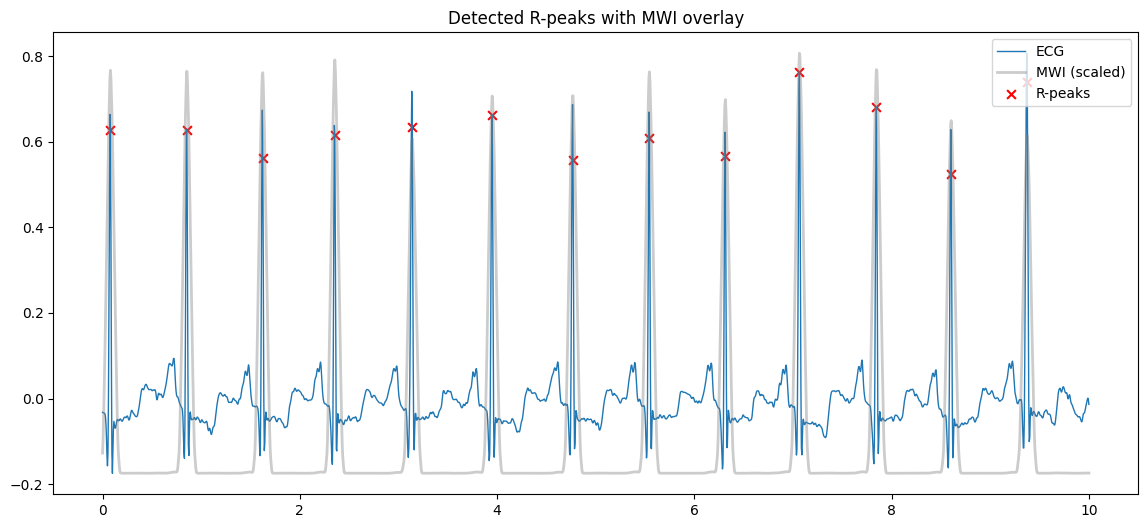

In [6]:
# just one of the signals with visualization

# you can comment this out if you dont want to see this,
# step after it will estimate HR for every signal
df = processed_signals[101]

peaks_idx, ecg_mwi, hr = detect_r_peaks_pan_tomkins(df)

print("Estimated HR:", hr)

plot_detection(df, peaks_idx, ecg_mwi)

In [7]:
estimated_hr = []
all_peaks = []

for df in processed_signals:

    peaks_idx, ecg_mwi, hr = detect_r_peaks_pan_tomkins(df)

    estimated_hr.append(hr)
    all_peaks.append(peaks_idx)

# estimated HR for each signal will not be used further on.


## Step 3

Extract features from the shape of the heart cycles: e.g., amplitude and duration of QRS complex, duration of the ST segment, T-wave duration


In [10]:
# Step 3: feature extraction from heartbeat shape
# maybe can be improved? More detailed comments missing and better understanding
def extract_features_from_signal(df_signal: pd.DataFrame, r_peaks: np.ndarray, fs: int = 200) -> dict:
    # input is one signal and detected r_peaks from that signal
    # output: 5 features from the signal

    # get one signal
    ecg = df_signal["ecg"].values
    n = len(ecg)

    
    qrs_amp_vals = []
    qrs_dur_vals = []
    st_dur_vals = []
    t_dur_vals = []


    # around each detected peak
    for r in r_peaks:
        r = int(r)
        if r <= 0 or r >= n - 1:
            continue

        # Estimate local baseline from PR-like segment before R peak.
        b1 = max(0, r - int(0.20 * fs))
        b2 = max(0, r - int(0.12 * fs))
        baseline = np.median(ecg[b1:b2]) if b2 > b1 else np.median(ecg)

        # -------- QRS amplitude and duration --------
        qrs_l = max(0, r - int(0.06 * fs))
        qrs_r = min(n - 1, r + int(0.06 * fs))
        qrs_seg = ecg[qrs_l:qrs_r + 1]

        qrs_amp = float(np.max(qrs_seg) - np.min(qrs_seg))
        qrs_amp_vals.append(qrs_amp)

        qrs_abs = np.abs(qrs_seg - baseline)
        if np.max(qrs_abs) > 0:
            qrs_thr = 0.25 * np.max(qrs_abs)
            qrs_idx = np.where(qrs_abs >= qrs_thr)[0]
            if len(qrs_idx) >= 2:
                qrs_on = qrs_l + int(qrs_idx[0])
                qrs_off = qrs_l + int(qrs_idx[-1])
                qrs_dur_vals.append((qrs_off - qrs_on) / fs)
            else:
                qrs_off = r
        else:
            qrs_off = r

        # -------- ST segment duration and T-wave duration --------
        # Start search a bit after QRS ends
        t_search_start = min(n - 1, qrs_off + int(0.04 * fs))
        t_search_end = min(n - 1, qrs_off + int(0.50 * fs))

        if t_search_end <= t_search_start + 2:
            continue

        t_seg = ecg[t_search_start:t_search_end + 1]
        t_dev = np.abs(t_seg - baseline)
        t_peak_rel = int(np.argmax(t_dev))
        t_peak = t_search_start + t_peak_rel

        if np.max(t_dev) <= 0:
            continue

        t_thr = 0.15 * np.max(t_dev)
        t_active = np.where(t_dev >= t_thr)[0]
        if len(t_active) < 2:
            continue

        t_on = t_search_start + int(t_active[0])
        t_off = t_search_start + int(t_active[-1])

        st_dur_vals.append(max(0.0, (t_on - qrs_off) / fs))
        t_dur_vals.append(max(0.0, (t_off - t_on) / fs))

    def safe_stat(values, reducer=np.mean):
        return float(reducer(values)) if len(values) > 0 else np.nan

    # return all of the extracted features
    features = {
        "n_beats": int(len(r_peaks)),
        "qrs_amp_mean": safe_stat(qrs_amp_vals, np.mean),
        "qrs_amp_std": safe_stat(qrs_amp_vals, np.std),
        "qrs_dur_mean_ms": safe_stat(qrs_dur_vals, np.mean) * 1000,
        "st_dur_mean_ms": safe_stat(st_dur_vals, np.mean) * 1000,
        "t_wave_dur_mean_ms": safe_stat(t_dur_vals, np.mean) * 1000,
    }
    return features


# go over all the pre processed signals and extract features, save them to data frame
feature_rows = []
for i, (df_signal, r_peaks) in enumerate(zip(processed_signals, all_peaks)):
    f = extract_features_from_signal(df_signal, r_peaks, fs=200)
    f["label"] = class_labels[i] if i < len(class_labels) else "unknown"
    feature_rows.append(f)

features_df = pd.DataFrame(feature_rows)

print("Extracted feature rows", len(features_df), "out of", len(processed_signals))
#print(features_df[["qrs_amp_mean", "qrs_amp_std", "qrs_dur_mean_ms", "st_dur_mean_ms", "t_wave_dur_mean_ms", "label"]].head())


Extracted feature rows 7901 out of 7901


## Step 4 & 5

Divide your dataset into the training set and test set (70-30% split)

Standardize your data: i.e., use the mean and standard deviation of the training data to
standardize the training data and the test data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# all numeric features except the class label for model input (X)
feature_cols = [c for c in features_df.columns if c != "label"]
X = features_df[feature_cols].copy()

# binary targets (abnormal=1, normal=0).
y = features_df["label"].map({"normal": 0, "abnormal": 1}).astype(int)

# 70/30 stratified split
# we can change random_state?
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=34,
    stratify=y
)

# step 5: Standardize the data
scaler = StandardScaler()
# training data
X_train_scaled = scaler.fit_transform(X_train)
# test data
X_test_scaled = scaler.transform(X_test)

# prepare for classifiers
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
#X_train shape: (5530, 6)
# X_test shape: (2371, 6)

# | label 0 = normal | label 1 = abnormal |


X_train shape: (5530, 6)
X_test shape:  (2371, 6)


## Step 6

Select two supervised machine learning algorithms and train two classifiers using the train set. Each classifier should predict 1 in the presence of arrhythmia or 0 otherwise.

In [19]:
#building pipelines for both classifiers
# Classifier 1: SVM
svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     svm.SVC(kernel='rbf', C=1, gamma='scale', random_state=34))
])

# Classifier 2: Gradient Boosting
gb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     GradientBoostingClassifier(
                    n_estimators=200, learning_rate=0.1,
                    max_depth=4, subsample=0.8, random_state=34))
])

# train
svm_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)
print("Classifier training done")

Classifier training done


In [27]:
#cross validation (on full dataset)
svm_cv = cross_val_score(svm_pipeline, X, y, cv=5, scoring='accuracy')
gb_cv  = cross_val_score(gb_pipeline,  X, y, cv=5, scoring='accuracy')

print(f"SVM  cross validation scores: {svm_cv.round(4)}  → mean: {svm_cv.mean():.4f}")
print(f"GB   cross validation scores: {gb_cv.round(4)}   → mean: {gb_cv.mean():.4f}")

SVM  cross validation scores: [0.8469 0.6911 0.6551 0.693  0.7513]  → mean: 0.7275
GB   cross validation scores: [0.7995 0.6652 0.6715 0.6778 0.7405]   → mean: 0.7109


## Step 7

Compare the two classifiers by evaluating the results using the test set.

- Obtain the confusion matrix, accuracy, precision, recall, and F1-score. These can be calculated from the predicted and true values.

---------- Support Vector Machine ----------
Accuracy:    0.8798
Precision:   0.8946
Recall:      0.8674
F1-Score:    0.8808


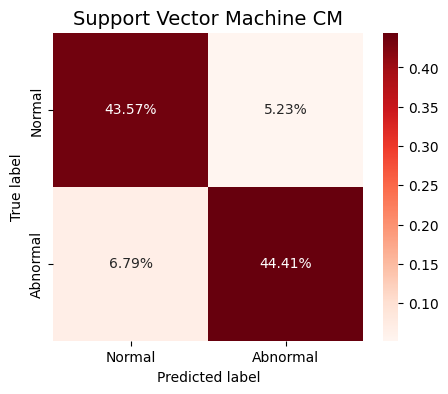



---------- Gradient boosting ----------
Accuracy:    0.9000
Precision:   0.9074
Recall:      0.8962
F1-Score:    0.9018


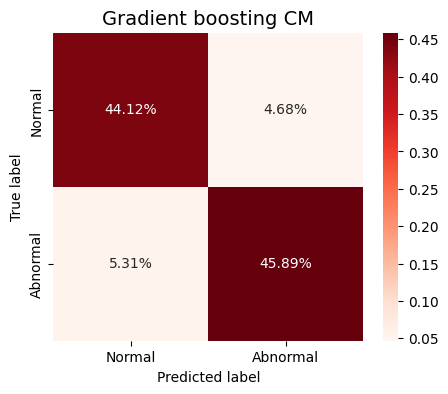

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_and_print_metrics(classifier_name, y_true, y_pred, pos_label=1):
    """
    Calculates and prints the accuracy, precision, recall, F1-score, and plots the confusion matrix
    for a given set of true and predicted labels.
    """
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    # print results / metrics
    print(f"---------- {classifier_name} ----------")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Recall:      {rec:.4f}")
    print(f"F1-Score:    {f1:.4f}")
    
    # plot cm
    plt.figure(figsize=(5, 4))
    # We use "Normal" and "Abnormal" for our particular labels
    sns.heatmap(cm / np.sum(cm), annot=True, fmt='.2%', cmap='Reds', 
                xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"])
    plt.title(f'{classifier_name} CM', fontsize=14)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()
    print("\n")

# generate predictions first
y_pred_svm = svm_pipeline.predict(X_test)
y_pred_gb = gb_pipeline.predict(X_test)

# SVM
evaluate_and_print_metrics("Support Vector Machine", y_test, y_pred_svm, pos_label=1)

# grad boost
evaluate_and_print_metrics("Gradient boosting", y_test, y_pred_gb, pos_label=1)

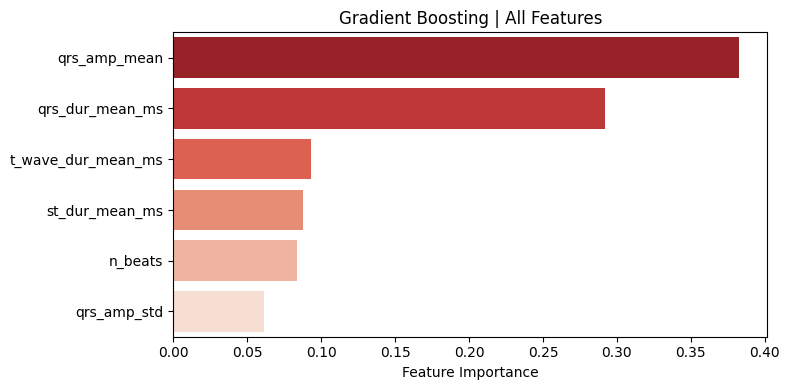

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# plot feat importance for every model
def plot_feature_importances(classifier_name, model, feature_names):
        
    importances = model.feature_importances_
    
    # sort importances for plotting
    indices = np.argsort(importances)[::-1]
    sorted_importances = importances[indices]
    sorted_features = np.array(feature_names)[indices]
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=sorted_importances, y=sorted_features, hue=sorted_features, palette='Reds_r', legend=False)
    plt.title(f"{classifier_name} | All Features")
    plt.xlabel("Feature Importance")
    plt.tight_layout()
    plt.show()

# feature_cols is predefined from earlier steps
feature_names = np.array(feature_cols)

plot_feature_importances("Gradient Boosting", gb_pipeline.named_steps['clf'], feature_names)
# SVM does not expose feature_importances_


# Additional Feature Extraction


The extracted features so far: qrs_amp_mean, qrs_dur_mean_ms, t_wave_dur_mean_ms, st_dur_mean_ms, n_beats, qrs_amp_std

As we were not satisfied with the accuracies we got, we pushed a bit further with feat extraction and improving the accuracy

Now we are going to extract additional featurs focusing on two categories: 1) Heart Rate Variability 2) Time-Frequency Domain

In [39]:
# Heart Rate Variability feature extraction
# 1) Standard Deviation of all RR intervals (SDNN)
# 2) Root Mean Squared Successive Differences (RMSSD)
# 3) pNN50: percentage of successive RR-intervals that differ more than 50 milliseconds


# an empty list to store our rows 
hrv_data = []

for r_peaks in all_peaks:
    # at least 3 peaks necessary to get 2 RR intervals for RMSSD/pNN50 math to work properly
    if len(r_peaks) > 2: 
        # Convert to seconds
        rr_intervals = np.diff(r_peaks) / 200.0  
        
        # Calculate successive differences once to save compute time
        rr_diff = np.diff(rr_intervals) 
        
        row = {
            'sdnn': np.std(rr_intervals, ddof=1), 
            'rmssd': np.sqrt(np.mean(rr_diff**2)),
            'pnn50': (np.sum(np.abs(rr_diff) > 0.05) / len(rr_diff)) * 100 
        }
    else:
        # Handle missing data
        row = {
            'sdnn': np.nan,
            'rmssd': np.nan,
            'pnn50': np.nan
        }
    
    hrv_data.append(row)

# Convert the list of dictionaries into a DataFrame in one fast operation
hrv_df = pd.DataFrame(hrv_data)


In [40]:
import pywt

# function to extract statistical features from DWT coefficients of an ECG
def extract_dwt_features(ecg_signal, waveletname='db4', level=4):
    """    
    Input:
        ecg_signal: The raw 1D continuous ECG signal.
        waveletname: The type of wavelet (db4 is standard for ECG).
        level: Decomposition level.
        
    Returns:
        additional features
    """

    # discrete wavelet transform
    # returns [cA4, cD4, cD3, cD2, cD1] for a level 4 decomposition
    coeffs = pywt.wavedec(ecg_signal, waveletname, level=level)
    
    coeff_names = [f'cA{level}'] + [f'cD{i}' for i in range(level, 0, -1)]
    
    # get features from the signal
    features = {}
    for name, coeff in zip(coeff_names, coeffs):
        # energy of the signal
        features[f'{name}_energy'] = np.sum(np.square(coeff))
        # Variance - captures how much the signal fluctuates in this band
        features[f'{name}_var'] = np.var(coeff)
        # std & mean
        features[f'{name}_std'] = np.std(coeff)
        features[f'{name}_mean'] = np.mean(coeff)
        
    return features

In [ ]:


dwt_data = []

# Loop through your raw continuous ECG signals
for raw_signal in processed_signals: 
    # Extract the features (this will return a dictionary of 20 features)
    features = extract_dwt_features(raw_signal)
        
    dwt_data.append(features)

# to DataFrame
dwt_df = pd.DataFrame(dwt_data)

print(f"Extracted DWT features {dwt_df.shape} out of", len(processed_signals), "signals")


# merge features
combined_df = pd.concat([
    features_df.reset_index(drop=True),
    hrv_df.reset_index(drop=True),
    dwt_df.reset_index(drop=True)
], axis=1)

print(f"\nShape after merge: {combined_df.shape}")

# clean signals that are noisy or didnt produce hrv/dwt

# remove rows where HRV or DWT did not succeed
final_clean_df = combined_df.dropna(subset=['sdnn', 'rmssd', 'pnn50', 'cA4_energy'])
# remove noise
outlier_mask = (final_clean_df['sdnn'] < 0.5) & (final_clean_df['rmssd'] < 0.5)
final_clean_df = final_clean_df[outlier_mask]

print(f"Shape of final, clean dataset: {final_clean_df.shape}")

c:\Users\jakob\AppData\Local\Programs\Python\Python310\lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Extracted DWT features (7901, 20) out of 7901 signals

Shape after merge: (7901, 30)
Shape of final, clean dataset: (7133, 30)


# Training with Additional Features

In [54]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# split data in X (features) and y (labels)
X = final_clean_df.drop(columns=['label']) 
y = final_clean_df['label']

# convert to 0 (normal) and 1 (abnormal)
y = y.map({'normal': 0, 'abnormal': 1}).astype(int)

# split 70 train - 30 test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


print("=== 1. Support Vector Machine (SVM) Hyperparameter Tuning ===")

# base
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('pca', PCA()), 
    ('classifier', SVC(class_weight='balanced', random_state=42))
])

# define possible params
svm_param_grid = {
    'pca__n_components': [0.85, 0.90, 0.95],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1]
}

# run GridSearchCV
svm_grid_search = GridSearchCV(
    estimator=svm_pipeline, 
    param_grid=svm_param_grid, 
    cv=5, 
    scoring='f1',
    n_jobs=-1 
)

# Fit the grid search on the training data
svm_grid_search.fit(X_train, y_train)

print(f"Best SVM F1-Score (CV): {svm_grid_search.best_score_:.3f}")
print(f"Best SVM Parameters: {svm_grid_search.best_params_}")


print("\n=== 2. Gradient Boosting Model (GBM) Hyperparameter Tuning ===")

# base
gbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# possible params
gbm_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7]
}

# Run GridSearchCV
gbm_grid_search = GridSearchCV(
    estimator=gbm_pipeline, 
    param_grid=gbm_param_grid, 
    cv=5, 
    scoring='f1',
    n_jobs=-1
)

gbm_grid_search.fit(X_train, y_train)

print(f"Best GBM F1-Score (CV): {gbm_grid_search.best_score_:.3f}")
print(f"Best GBM Parameters: {gbm_grid_search.best_params_}")

=== 1. Support Vector Machine (SVM) Hyperparameter Tuning ===
Best SVM F1-Score (CV): 0.885
Best SVM Parameters: {'classifier__C': 10.0, 'classifier__gamma': 'scale', 'pca__n_components': 0.95}

=== 2. Gradient Boosting Model (GBM) Hyperparameter Tuning ===
Best GBM F1-Score (CV): 0.951
Best GBM Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 7, 'classifier__n_estimators': 200}


Tuned test set evaluations of the classifiers

---------- Support Vector Machine (Tuned) ----------
Accuracy:    0.8935
Precision:   0.8904
Recall:      0.8778
F1-Score:    0.8840


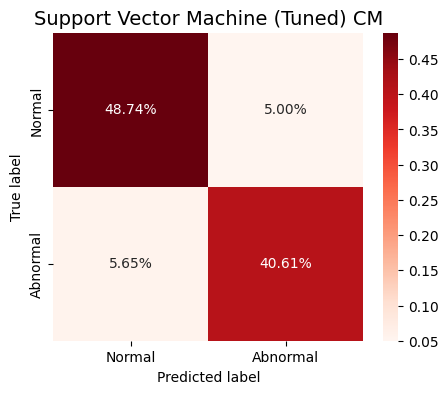



---------- Gradient Boosting (Tuned) ----------
Accuracy:    0.9472
Precision:   0.9452
Recall:      0.9404
F1-Score:    0.9428


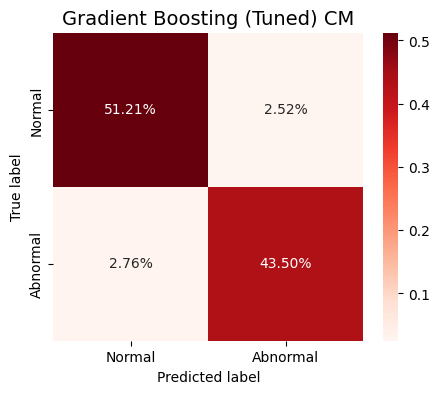

In [55]:
print("Tuned test set evaluations of the classifiers\n")

# Generate predictions directly from the tuned grid search models
y_pred_svm_tuned = svm_grid_search.predict(X_test)
y_pred_gb_tuned = gbm_grid_search.predict(X_test)

# SVM
evaluate_and_print_metrics("Support Vector Machine (Tuned)", y_test, y_pred_svm_tuned, pos_label=1)

# Gradient Boosting
evaluate_and_print_metrics("Gradient Boosting (Tuned)", y_test, y_pred_gb_tuned, pos_label=1)

Feature Importance Analysis (Tuned)



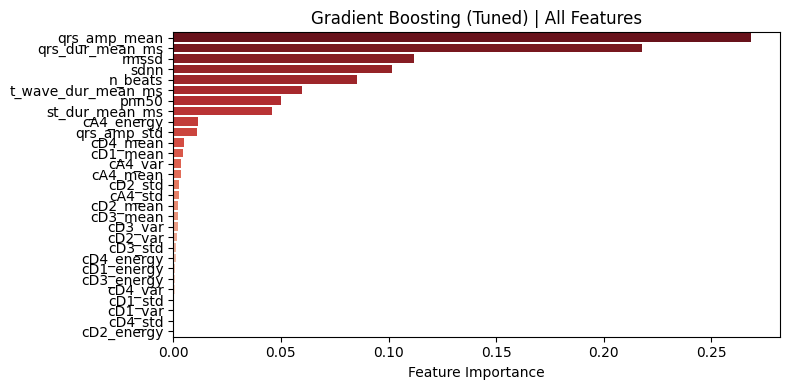

In [58]:
print("Feature Importance Analysis (Tuned)\n")
\
best_gbm_model = gbm_grid_search.best_estimator_.named_steps['classifier']

feature_names_tuned = X.columns.to_numpy()

plot_feature_importances("Gradient Boosting (Tuned)", best_gbm_model, feature_names_tuned)
# SVM doesnt have feat importance